In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
from smrt.permittivity.saline_snow import saline_snow_permittivity_geldsetzer09 as geldsetzer

In [2]:
m=r'$\degree$'

In [3]:
df=pd.read_excel('../data/Flood_geophys.ods',sheet_name='big_analysis')

e=[]
for density,salinity,temp in zip(df['Density'],df['Salinity'],df['Temp']):


    e.append(geldsetzer(frequency=13e9,
                 density=density*1000,
                 salinity=salinity/1000,
                 temperature=temp+273.15,
                ))

df['e_ku']=e

df['n']=np.sqrt(df['e_ku'])

df['e_real_ku']=[x.real for x in e]
df['e_imag_ku']=[x.imag for x in e]


e=[]
for density,salinity,temp in zip(df['Density'],df['Salinity'],df['Temp']):


    e.append(geldsetzer(frequency=50e6,
                 density=density*1000,
                 salinity=salinity/1000,
                 temperature=temp+273.15,
                ))
    
df['e_real_50']=[x.real for x in e]
df['e_imag_50']=[x.imag for x in e]


df['loss_tangent_50']=df['e_imag_50']/df['e_real_50']

df

,Pit,Salinity,Density,Dielectric,loss,BW,Depth,Temp,e_ku,n,e_real_ku,e_imag_ku,e_real_50,e_imag_50,loss_tangent_50
0,2,0.01,0.238877,1.78322,0.30923,0,26-21,-6.8,1.609812+ 0.002677j,1.268784+0.001055j,1.609812,0.002677,1.610775,0.002018,0.001253
1,2,0.07,0.262715,1.79123,0.31632,0,21-16,-6.4,1.675513+ 0.007631j,1.294419+0.002948j,1.675513,0.007631,1.683491,0.002479,0.001473
2,2,0.06,0.252776,1.77267,0.41786,0,16-11,-5.2,1.650432+ 0.008026j,1.284695+0.003124j,1.650432,0.008026,1.658896,0.002445,0.001474
3,2,0.42,0.230247,1.89312,0.44343,0,11-6,-4.5,1.630975+ 0.047897j,1.277234+0.018750j,1.630975,0.047897,1.695200,0.014404,0.008497
4,2,8.47,0.386468,3.82654,2.16544,1,5-0,-2.7,4.515334+ 2.825861j,2.218337+0.636932j,4.515334,2.825861,8.414122,10.162806,1.207827
5,3,0.01,0.294582,1.83743,0.52578,0,23-18,-6.4,1.752079+ 0.002902j,1.323661+0.001096j,1.752079,0.002902,1.753357,0.002026,0.001156
6,3,0.40,0.279762,1.92632,0.61834,0,18-13,-5.2,1.756548+ 0.046477j,1.325464+0.017532j,1.756548,0.046477,1.818967,0.015620,0.008588
7,3,0.50,0.257586,1.91933,0.59367,0,13-8,-4.5,1.715231+ 0.063134j,1.309890+0.024099j,1.715231,0.063134,1.800757,0.022466,0.012476
8,3,5.57,0.331860,4.19146,1.96879,1,8-3,-2.7,3.285060+ 1.600164j,1.862675+0.429534j,3.285060,1.600164,5.502450,3.733720,0.678556
9,3,6.07,0.309012,4.39241,2.02311,1,3-0,-2.4,3.438073+ 1.852759j,1.916193+0.483448j,3.438073,1.852759,6.008725,4.268783,0.710431


In [13]:
df_dry = df[df['BW']==0]
print(df_dry.shape)
np.mean(df_dry['e_ku'])
np.nanstd(df_dry['e_real_ku']),np.nanstd(df_dry['e_imag_ku'])

(21, 15)


(np.float64(0.07438818657458394), np.float64(0.02370980131384366))

In [17]:
def calculate_phase_velocity(epsilon_prime, epsilon_double_prime, c=299792458):
    # 1. Calculate the loss tangent (e'' / e')
    loss_tangent = epsilon_double_prime / epsilon_prime
    
    # 2. Compute the exact denominator based on the propagation constant formula
    inner_term = np.sqrt(1 + loss_tangent**2)
    denominator = np.sqrt((epsilon_prime / 2.0) * (inner_term + 1))
    
    # 3. Calculate phase velocity
    v_p = c / denominator
    
    return v_p

df_wet=df[df['BW']==1]

df_wet['pv'] = calculate_phase_velocity(df_wet['e_real_ku'],df_wet['e_imag_ku'])/299792458
df_wet

/tmp/ipykernel_16395/4172950337.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_wet['pv'] = calculate_phase_velocity(df_wet['e_real_ku'],df_wet['e_imag_ku'])/299792458


,Pit,Salinity,Density,Dielectric,loss,BW,Depth,Temp,e_ku,n,e_real_ku,e_imag_ku,e_real_50,e_imag_50,loss_tangent_50,pv
4,2,8.47,0.386468,3.82654,2.16544,1,5-0,-2.7,4.515334+ 2.825861j,2.218337+0.636932j,4.515334,2.825861,8.414122,10.162806,1.207827,0.450788
8,3,5.57,0.331860,4.19146,1.96879,1,8-3,-2.7,3.285060+ 1.600164j,1.862675+0.429534j,3.285060,1.600164,5.502450,3.733720,0.678556,0.536862
9,3,6.07,0.309012,4.39241,2.02311,1,3-0,-2.4,3.438073+ 1.852759j,1.916193+0.483448j,3.438073,1.852759,6.008725,4.268783,0.710431,0.521868
13,4,7.58,0.375363,3.88213,1.92679,1,8-3,-2.9,4.001142+ 2.266144j,2.073579+0.546433j,4.001142,2.266144,7.129517,7.432782,1.042537,0.482258
14,4,9.10,0.373877,4.28367,2.11821,1,3-0,-2.0,5.538820+ 4.096311j,2.492771+0.821638j,5.538820,4.096311,11.209875,14.255657,1.271705,0.401160
18,5,10.08,0.431810,3.44143,2.09712,1,8-3,-2.5,5.732153+ 4.094296j,2.527485+0.809955j,5.732153,4.094296,11.368183,17.976095,1.581264,0.395650
19,5,9.29,0.422119,3.26901,1.99232,1,3-0,-2.1,6.004126+ 4.479787j,2.597626+0.862285j,6.004126,4.479787,12.192656,17.551734,1.439533,0.384967
24,6,2.44,0.277746,2.11032,1.08723,1,11-6,-3.4,2.123913+ 0.451661j,1.465489+0.154099j,2.123913,0.451661,2.750039,0.511438,0.185975,0.682366
25,6,15.05,0.585945,5.82134,2.67234,1,5-0,-2.6,9.469042+ 7.933429j,3.303200+1.200870j,9.469042,7.933429,20.256345,59.446722,2.934721,0.302737
30,7,1.39,0.278029,2.17324,1.18321,1,16-11,-4.1,1.902796+ 0.207329j,1.381458+0.075040j,1.902796,0.207329,2.189280,0.158029,0.072183,0.723873


In [26]:
q=df_wet[['Salinity','Temp','Density','e_real_ku','e_imag_ku','pv']]
q=q.loc[[4,9,14,19,25,32]]
q['Pit']=np.arange(2,8)
q.set_index('Pit',inplace=True)
q.to_csv('wet_dielectrics.csv')

(array([2., 1., 1., 2., 2., 1., 1., 0., 0., 2.]),
 array([0.2537858 , 0.3007945 , 0.3478032 , 0.3948119 , 0.4418206 ,
        0.4888293 , 0.535838  , 0.5828467 , 0.6298554 , 0.67686409,
        0.72387279]),
 <BarContainer object of 10 artists>)

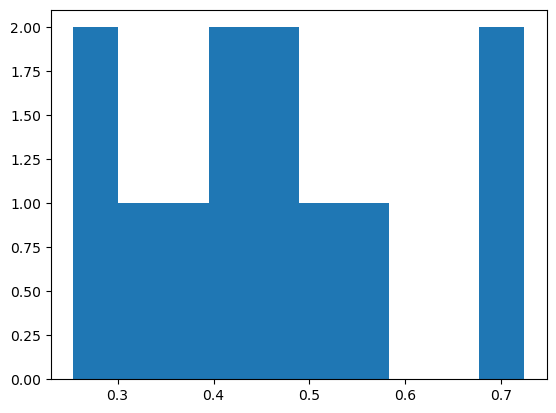

In [19]:
plt.hist(df_wet['pv'])

In [30]:
fresnels=[]
for p in [(3,4),(7,8),(12,13),(17,18),(24,25),(30,31)]:
    n_snow=df.iloc[p[0]]['e_ku']
    n_ice=df.iloc[p[1]]['e_ku']
    fresnels. append(abs(  (n_snow-n_ice)/(n_snow+n_ice) ) **2 )
print(fresnels,np.nanmean(fresnels))

[np.float64(0.3483523892357454), np.float64(0.1738175967893912), np.float64(0.28538001671762214), np.float64(0.4651591978101934), np.float64(0.5370023024609359), np.float64(0.6447915690642135)] 0.4090838453463503


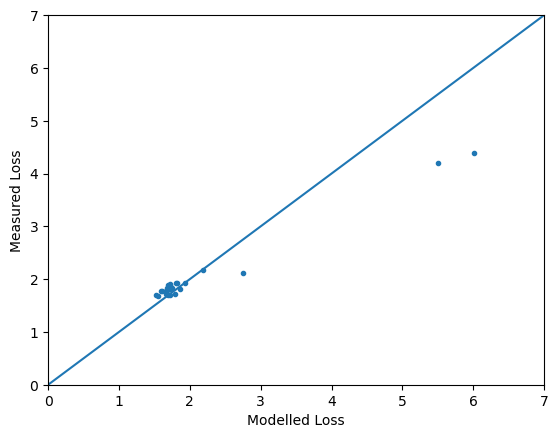

In [30]:
plt.scatter(df['e_real_50'],df['Dielectric'],marker='.')
# plt.scatter(df['loss_tangent_50'],df['loss'],marker='.')
plt.xlabel('Modelled Loss')
plt.ylabel('Measured Loss')
plt.xlim(0,7)
plt.ylim(0,7)
plt.plot([0,7],[0,7])

In [17]:
df_wet = df[df['BW']==1]
df_dry = df[df['BW']==0]
df_wet.shape,df_dry.shape,df.columns

((12, 13),
 (21, 13),
 Index(['Pit', 'Salinity', 'Density', 'Dielectric', 'loss', 'BW', 'Depth',
        'Temp', 'e_real_ku', 'e_imag_ku', 'e_real_50', 'e_imag_50',
        'loss_tangent_50'],
       dtype='str'))

In [20]:
for variable in ['e_real_ku','e_imag_ku']:
    print(variable)
    print(np.nanmean(df_dry[variable]),
          np.nanstd(df_dry[variable]),
          np.nanmean(df_wet[variable]),
          np.nanstd(df_wet[variable]))

e_real_ku
1.6780687232291056 0.07438818657458394 5.87381349350947 3.462235759537785
e_imag_ku
0.02319704575691906 0.02370980131384366 4.251841242334959 3.507252173430308


In [9]:
print('Salinity')
np.nanmean(df_dry['Salinity']),np.nanstd(df_dry['Salinity']),np.nanmean(df_wet['Salinity']),np.nanstd(df_wet['Salinity'])

Salinity


(np.float64(0.17959999999999998),
 np.float64(0.1884776909875543),
 np.float64(9.256666666666666),
 np.float64(5.194924339091849))

In [11]:
print('Salinity')
np.nanmean(df_dry['Density']),np.nanstd(df_dry['Density']),np.nanmean(df_wet['Density']),np.nanstd(df_wet['Density'])

Salinity


(np.float64(0.2351092876872),
 np.float64(0.06362544719587278),
 np.float64(0.43992419421666673),
 np.float64(0.1616802608181218))

In [12]:
np.nanmean(df_dry['Dielectric']),np.nanstd(df_dry['Dielectric']),np.nanmean(df_wet['Dielectric']),np.nanstd(df_wet['Dielectric'])

(np.float64(1.8033116),
 np.float64(0.08350620210164034),
 np.float64(4.1245525),
 np.float64(1.2795750148201874))

In [13]:
np.nanmean(df_dry['loss']),np.nanstd(df_dry['loss']),np.nanmean(df_wet['loss']),np.nanstd(df_wet['loss'])

(np.float64(0.4482252),
 np.float64(0.15843970262835008),
 np.float64(2.20754),
 np.float64(0.7759187358759506))

In [95]:
def make_temp_plot_before(ax,legend=False):
    
    df=pd.read_excel('../data/Flood_geophys.ods',sheet_name='23_temp')
    
    colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink']
    
    for col,c in zip(df.columns,colors):
        
        l = df[col]
        ax.scatter([l[4]],[0],marker='o',color=c,s=60,fc='none')
        ax.scatter([l[0]],[6],marker='^',color=c,s=60,fc='none')
    
        ax.plot([l[4],l[3],l[3],l[2],l[2],l[1],l[1],l[0]],[0,0,2,2,4,4,6,6],color=c,label=f'Pit #{col}',linestyle=':')

    ax.set_xlabel(f'Temperature ({m}C)')
    ax.set_ylabel(f'Height Above Ice (cm)')

    
    ax.scatter([],[],marker='o',color='k',label='Snow/Ice\nInterface',fc='none')
    ax.scatter([],[],marker='^',color='k',label='Air/Snow\nInterface',fc='none')

    if legend:ax.legend(ncols=2)

def make_sal_plot_before(ax,legend=False):

    df=pd.read_excel('../data/Flood_geophys.ods',sheet_name='23_salinity')
    
    colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink']
    
    for col,c in zip(df.columns,colors):
        
        l = df[col]
        ax.scatter([l[3]],[0],marker='s',color=c,s=60,fc='none')
    
        ax.plot([l[3],l[2],l[2],l[1],l[1],l[0],l[0]],[0,0,2,2,4,4,6],color=c,label=f'Pit #{col}',linestyle=':')

    ax.scatter([],[],marker='s',color='k',label='Ice Surface\nScraping',fc='none')
    
    ax.set_xlabel(f'Salinity (ppt)')
    ax.set_ylabel(f'Height Above Ice (cm)')

    
    if legend:ax.legend(ncols=2)

def plot_temp(ax,df,num,ice_surf_temp,snow_surf_temp,color):
    
    df=df.iloc[1:-1]
    
    heights=[]
    temps=[]

    for h,t in zip(df.iloc[:,0],df.iloc[:,1]):
        heights += [int(x) for x in h.split('-')]
        temps.append(t)
        temps.append(t)
        
    ax.plot([snow_surf_temp]+temps+[ice_surf_temp],[heights[0]]+heights+[0],
            # label=f'P{num}',
            color=color,ls='-')
    ax.scatter([ice_surf_temp],[0],color=color,marker='o',fc='none')
    ax.scatter([snow_surf_temp],[heights[0]],color=color,marker='^',fc='none')

def make_temp_plot_after(ax):

    ice_surf_temps=[-2.1,-1.9,-2.2,-2.0,-2.0,-2.0,-2]
    snow_surf_temps = [-7.8,-7.2,-7.2,-7.4,-7.1,-7.3,-7.6]
        
    colors=['tab:blue','tab:orange','tab:green','tab:red','tab:purple','tab:brown','tab:pink']
        
    for i,c in zip(range(1,8),colors):
    
        df=pd.read_excel('../data/Flood_geophys.ods',sheet_name=f'p{i}_temp',header=None)
    
        plot_temp(ax,df,i,ice_surf_temp=ice_surf_temps[i-1],snow_surf_temp=snow_surf_temps[i-1],color=c)
        # make_temp_plot(ax)
    
    ax.scatter([],[],marker='o',color='k',label='Snow/Ice\nInterface',fc='none')
    ax.scatter([],[],marker='^',color='k',label='Air/Snow\nInterface',fc='none')

    ax.plot([],[],color='k',ls=':',label='Before')
    ax.plot([],[],color='k',ls='-',label='After')
    
    # ax.legend(ncols=2)
    ax.set_xlabel(f'Temperature ({m}C)')
    ax.set_ylabel('Height (cm)')
    ax.set_xlim(-12,0)


def make_sal_plot_after(ax):

    for num in range(1,8):
        df=pd.read_excel('../data/Flood_geophys.ods',sheet_name=f'p{num}_sal',header=None)
        heights=[]
        temps=[]
        for h,t in zip(df.iloc[:,0],df.iloc[:,1]):
            heights += [int(x) for x in h.split('-')]
            temps.append(t)
            temps.append(t)
            
        ax.plot(temps,heights,label=f'P{num}',ls='-')
    
    ax.set_xlabel(f'Salinity (ppt)')
    ax.set_ylabel('Height (cm)')
    ax.legend(ncols=2)


def make_core_plot(ax):

    df03=pd.read_excel('../data/Flood_geophys.ods',sheet_name=f'core03',header=None)
    df23=pd.read_excel('../data/Flood_geophys.ods',sheet_name=f'core23',header=None)

    linestyles=[':','-']
    for df,date,ls in zip([df23,df03],['23rd September\nPre-Flood','3rd October\nPost-Flood'],linestyles):
        heights=[]
        temps=[]
        for h,t in zip(df.iloc[:,0],df.iloc[:,1]):
            heights += [int(x) for x in h.split('-')]
            temps.append(t)
            temps.append(t)
    
        heights = np.array(heights)
        ax.plot(temps,(heights-heights[0])*-1,label=date,ls=ls,color='k')
    
    ax.set_xlabel(f'Salinity (ppt)')
    ax.set_ylabel('Depth Below Snow/Ice\nInterface (cm)')
    ax.set_ylim(40,0)
    ax.legend()

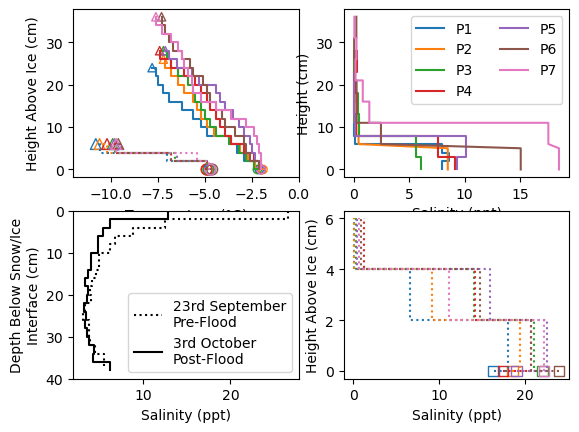

In [96]:
fig,axs=plt.subplots(2,2)

ax1,ax2,ax3,ax4=axs.reshape(-1)

make_temp_plot_after(ax1)
make_temp_plot_before(ax1)

make_sal_plot_after(ax2)

make_sal_plot_before(ax4)

make_core_plot(ax3)

plt.show()


In [78]:
df=pd.read_csv('../data/weather',delim_whitespace=True,skiprows=1,header=None)

df['dates'] = [datetime.datetime(int(x[:4]),int(x[5:7]),int(x[8:10])) for x in df.iloc[:,0]]

df['dts'] = [x+datetime.timedelta(hours=int(y)) for x,y in zip(df['dates'],df.iloc[:,1])]

df

/tmp/ipykernel_86840/3594381843.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df=pd.read_csv('../data/weather',delim_whitespace=True,skiprows=1,header=None)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,dates,dts
0,2023-09-21,0,-15.1,°C,-16.8,°C,—,0.0,mm,—,17.3,km/h,—,997.9,hPa,87,%,2023-09-21,2023-09-21 00:00:00
1,2023-09-21,1,-15.1,°C,-16.9,°C,—,0.0,mm,—,15.5,km/h,—,997.4,hPa,86,%,2023-09-21,2023-09-21 01:00:00
2,2023-09-21,2,-15.0,°C,-16.8,°C,—,0.0,mm,—,16.9,km/h,—,996.8,hPa,86,%,2023-09-21,2023-09-21 02:00:00
3,2023-09-21,3,-15.0,°C,-16.8,°C,—,0.0,mm,—,17.6,km/h,—,996.2,hPa,86,%,2023-09-21,2023-09-21 03:00:00
4,2023-09-21,4,-14.8,°C,-16.6,°C,—,0.0,mm,—,16.6,km/h,—,995.7,hPa,86,%,2023-09-21,2023-09-21 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355,2023-10-05,19,-5.6,°C,-9.8,°C,—,0.0,mm,—,18.7,km/h,—,965.2,hPa,72,%,2023-10-05,2023-10-05 19:00:00
356,2023-10-05,20,-5.7,°C,-9.9,°C,—,0.0,mm,—,17.6,km/h,—,965.3,hPa,72,%,2023-10-05,2023-10-05 20:00:00
357,2023-10-05,21,-5.7,°C,-8.9,°C,—,0.0,mm,—,15.8,km/h,—,965.3,hPa,78,%,2023-10-05,2023-10-05 21:00:00
358,2023-10-05,22,-5.7,°C,-9.2,°C,—,0.0,mm,—,16.6,km/h,—,965.3,hPa,76,%,2023-10-05,2023-10-05 22:00:00


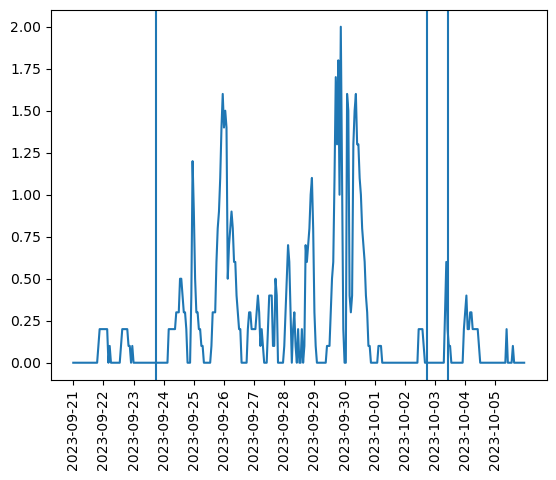

In [60]:
plt.plot(df['dts'],df.iloc[:,7])
plt.xticks(df['dts'][::24],rotation=90)
plt.axvline(datetime.datetime(2023,9,23,18))
plt.axvline(datetime.datetime(2023,10,2,18))
plt.axvline(datetime.datetime(2023,10,3,10))
plt.show()

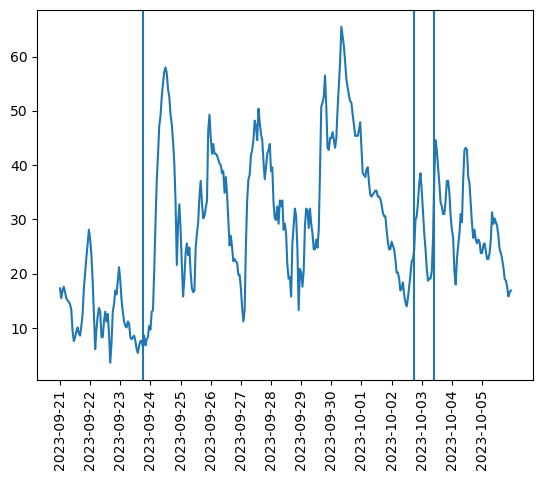

In [45]:
plt.plot(df['dts'],df.iloc[:,10])
plt.xticks(df['dts'][::24],rotation=90)
plt.axvline(datetime.datetime(2023,9,23,18))
plt.axvline(datetime.datetime(2023,10,2,18))
plt.axvline(datetime.datetime(2023,10,3,10))
plt.show()

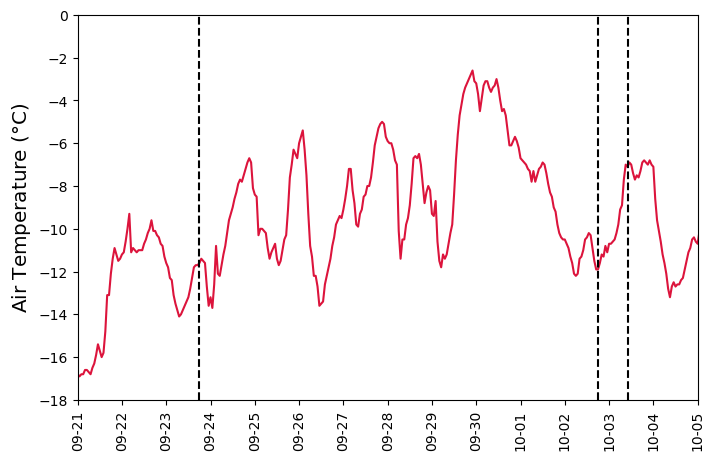

In [94]:
labels=[str(x)[5:10] for x in df['dts'][::24]]

plt.figure(figsize=(8,5))
plt.plot(df['dts'],df.iloc[:,4],color='crimson')
plt.xticks(df['dts'][::24],labels=labels,rotation=90)
plt.ylabel(f'Air Temperature ({m}C)',fontsize='x-large')
plt.axvline(datetime.datetime(2023,9,23,18),linestyle='--',color='k')
plt.axvline(datetime.datetime(2023,10,2,18),linestyle='--',color='k')
plt.axvline(datetime.datetime(2023,10,3,10),linestyle='--',color='k')
plt.xlim(datetime.datetime(2023,9,21,0),datetime.datetime(2023,10,5,0))
plt.ylim(-18,0)
dd='/home/robbie/Dropbox/Apps/Overleaf/Rothera_flooding/SuppFigs/'
plt.savefig(f'{dd}temp_timeseries.png',dpi=500)